[np.float64(0.0), np.float64(0.5774), np.float64(0.9107), np.float64(1.5773)]


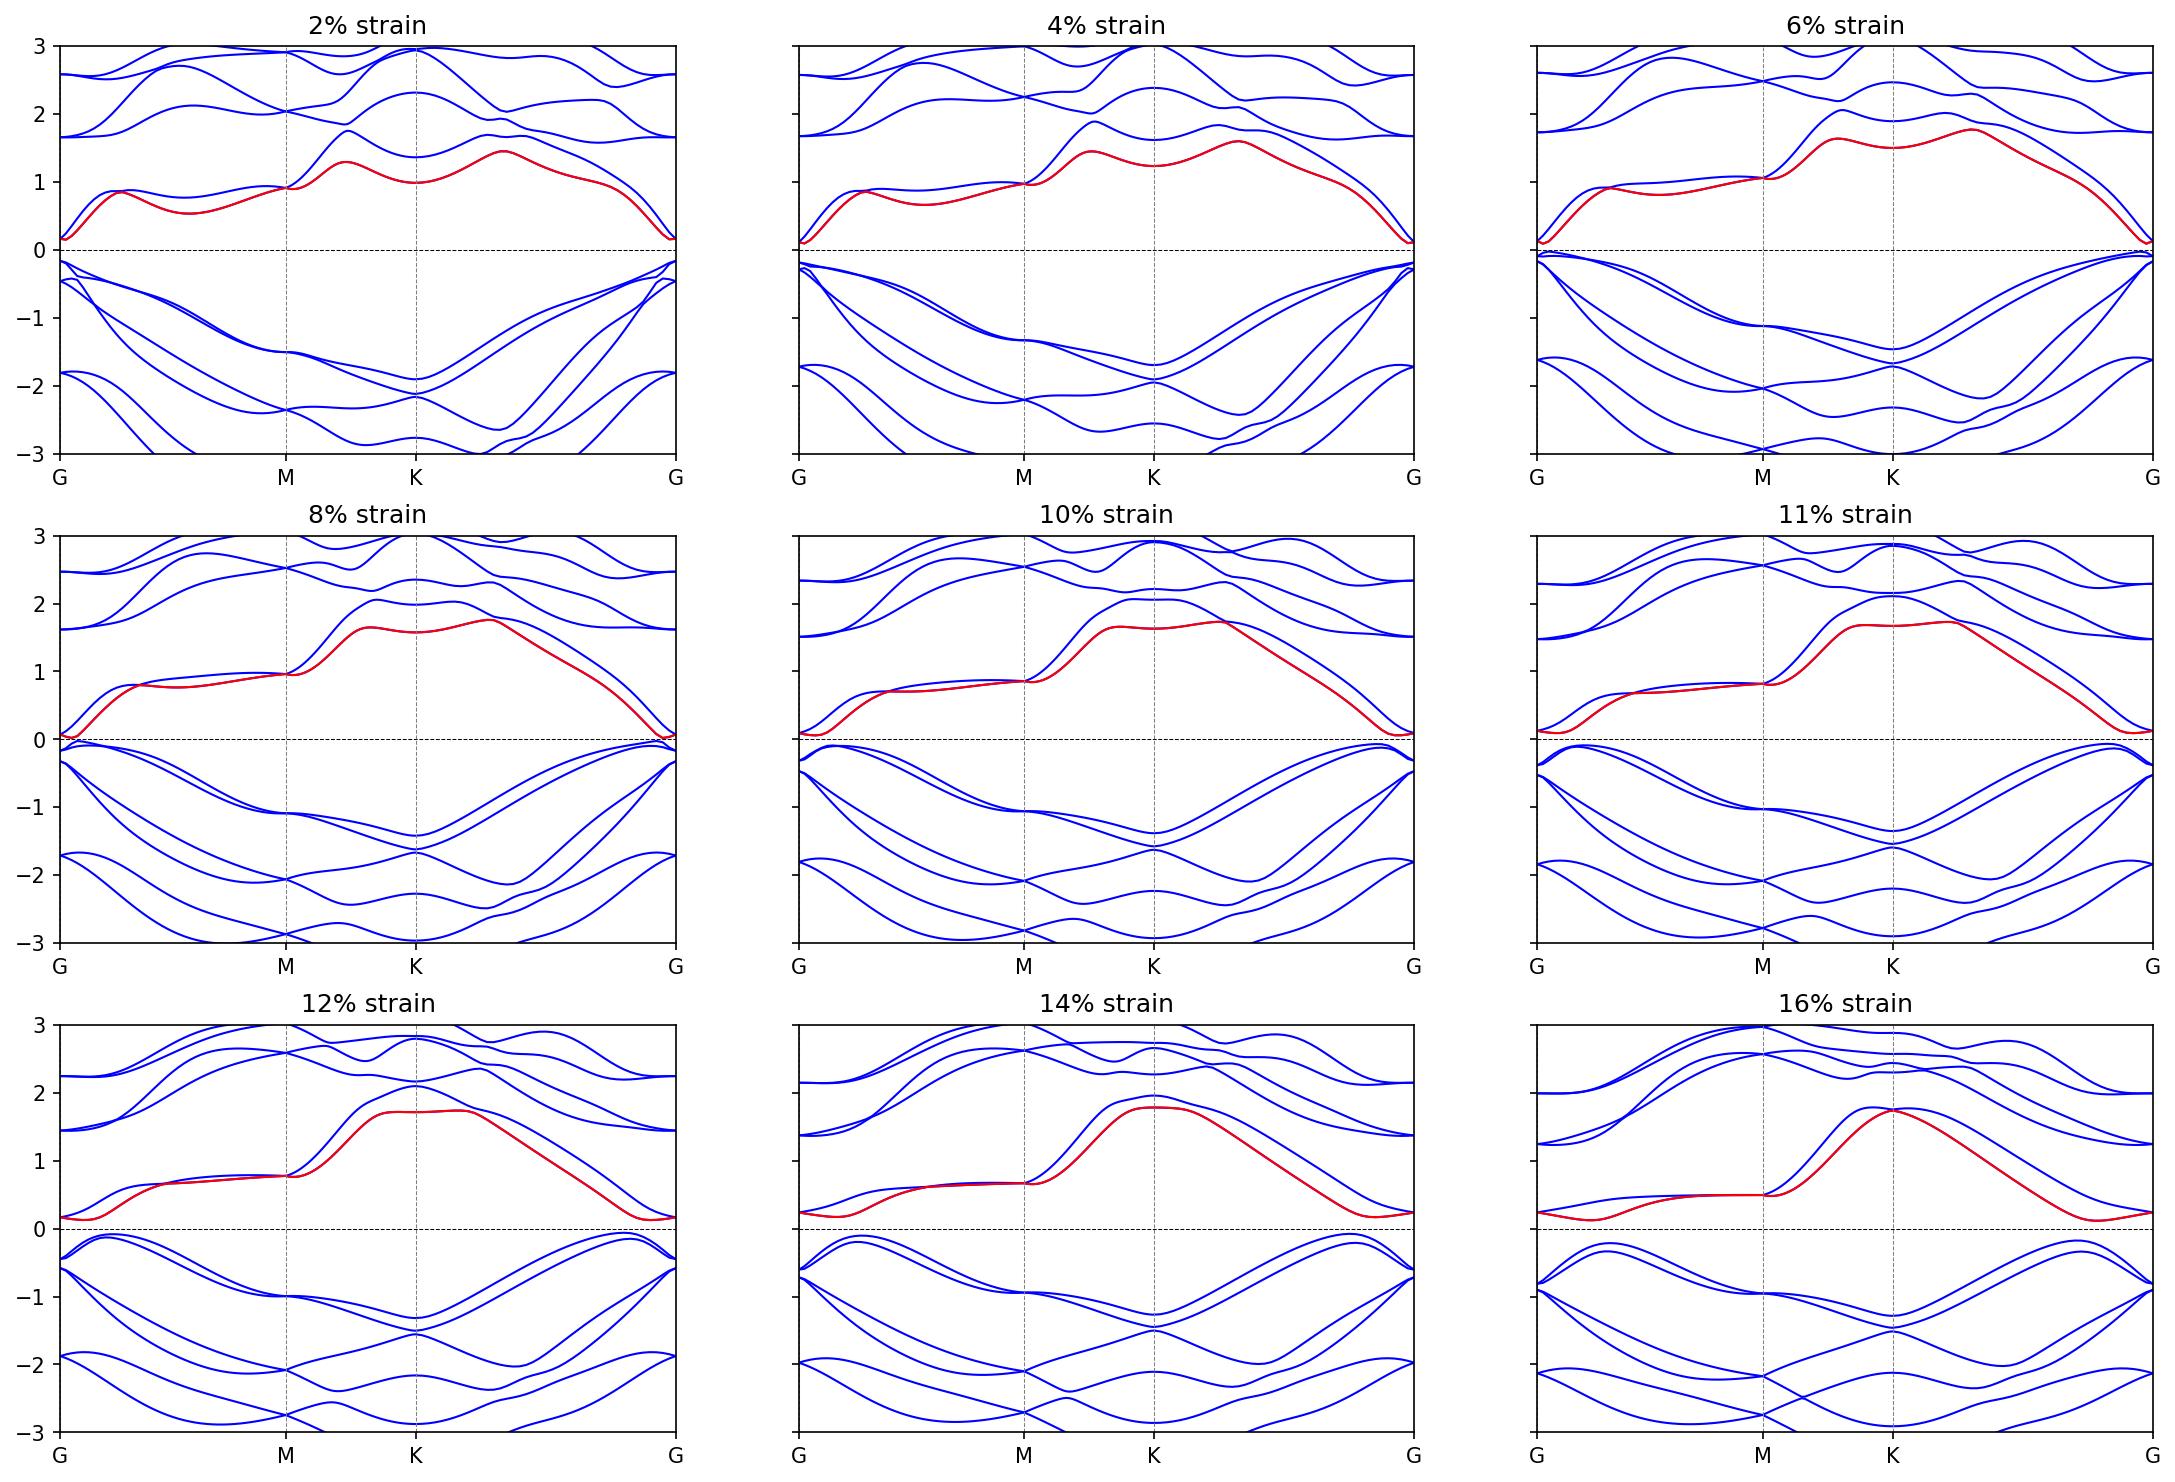

In [15]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np
%matplotlib inline

plt.rcParams["figure.dpi"]=150
plt.rcParams["figure.facecolor"]="white"
plt.rcParams["figure.figsize"]=(8, 6)

strains = [2,4,6,8,10,11,12,14,16]

fermi_levels = np.loadtxt("fermi_levels.dat")
fermi_levels = fermi_levels.T
fermi_dict = dict(zip(fermi_levels[0].astype(int), fermi_levels[1]))

high_sym_points = [fermi_levels[2][0],fermi_levels[3][0],fermi_levels[4][0],fermi_levels[5][0]]
high_sym_labels = ["G","M","K","G"]
print(high_sym_points)

n_plots = len(strains)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows),
                          sharey=True)
axes = axes.flatten()

datasets = {i: np.loadtxt(f"BiSb_{i}pct.bands.dat.gnu") for i in strains}

for ax, (idx, data) in zip(axes, datasets.items()):
# load data
    k = np.unique(data[:, 0])
    bands = np.reshape(data[:, 1], (-1, len(k)))
    for band in range(len(bands)):
        ax.plot(k, bands[band, :] -fermi_dict[idx] , linewidth=1, color='blue')
    ax.plot(k, bands[20, :] -fermi_dict[idx] , linewidth=1, color='red')
    ax.set_xlim(min(k), max(k))
    ax.axhline(0,color="black",lw=0.5,ls="--")
    for i in high_sym_points:
        ax.axvline(i,lw=0.5,ls="--",color="gray")
    ax.set_xticks(high_sym_points,high_sym_labels)
    ax.set_ylim(-3,3)
    ax.set_title(f"{idx}% strain")

In [11]:
"""
Parse QE-style spin-projection files (e.g. spinX.dat, spinY.dat, spinZ.dat)
and build, for each band, an array of columns [kx, ky, sx, sy, sz].

Usage:
    python parse_spin_texture.py spinX.dat spinY.dat spinZ.dat

Or import and call parse_spin_texture(fx, fy, fz) directly.
"""

import re
import sys
import numpy as np


def _parse_single_file(filepath):
    """Parse one spinX/Y/Z.dat file -> (kpoints (nks,3), spin (nks,nbnd), nbnd, nks)."""
    with open(filepath) as f:
        content = f.read()

    header_match = re.search(r'nbnd\s*=\s*(\d+)\s*,\s*nks\s*=\s*(\d+)', content)
    if not header_match:
        raise ValueError(f"Could not find nbnd/nks header in {filepath}")
    nbnd = int(header_match.group(1))
    nks = int(header_match.group(2))

    rest = content[header_match.end():]
    rest = rest.split('/', 1)[-1] if '/' in rest[:5] else rest

    floats = np.array([float(x) for x in re.findall(r'-?\d+\.\d+', rest)])

    expected = nks * (3 + nbnd)
    if floats.size != expected:
        raise ValueError(
            f"{filepath}: expected {expected} floats (nks*(3+nbnd)), got {floats.size}"
        )

    data = floats.reshape(nks, 3 + nbnd)
    kpoints = data[:, :3]
    spin = data[:, 3:]
    return kpoints, spin, nbnd, nks


def parse_spin_texture(file_sx, file_sy, file_sz):
    """
    Parse three spin-component files and return a dict:
        {band_index (1-based): array of shape (nks, 5)}
    where each row is [kx, ky, sx, sy, sz].

    Also returns kpoints (nks,3) and nbnd/nks for reference.
    """
    kx_full, sx, nbnd_x, nks_x = _parse_single_file(file_sx)
    ky_full, sy, nbnd_y, nks_y = _parse_single_file(file_sy)
    kz_full, sz, nbnd_z, nks_z = _parse_single_file(file_sz)

    if not (nbnd_x == nbnd_y == nbnd_z and nks_x == nks_y == nks_z):
        raise ValueError(
            f"Mismatched dimensions across files: "
            f"nbnd=({nbnd_x},{nbnd_y},{nbnd_z}) nks=({nks_x},{nks_y},{nks_z})"
        )

    # Sanity check that k-points line up across files
    if not np.allclose(kx_full, ky_full) or not np.allclose(kx_full, kz_full):
        raise ValueError("k-points differ between the three input files — "
                          "check that files correspond to the same calculation")

    kpoints = kx_full  # (nks, 3) -> kx, ky, kz
    nbnd, nks = nbnd_x, nks_x

    bands = {}
    for b in range(nbnd):
        arr = np.column_stack([
            kpoints[:, 0],   # kx
            kpoints[:, 1],   # ky
            sx[:, b],        # sx for this band
            sy[:, b],        # sy for this band
            sz[:, b],        # sz for this band
        ])
        bands[b + 1] = arr  # 1-indexed band number

    return bands, kpoints, nbnd, nks


bands, kpoints, nbnd, nks = parse_spin_texture("bisb_spintexture.dat.1", "bisb_spintexture.dat.2", "bisb_spintexture.dat.3")


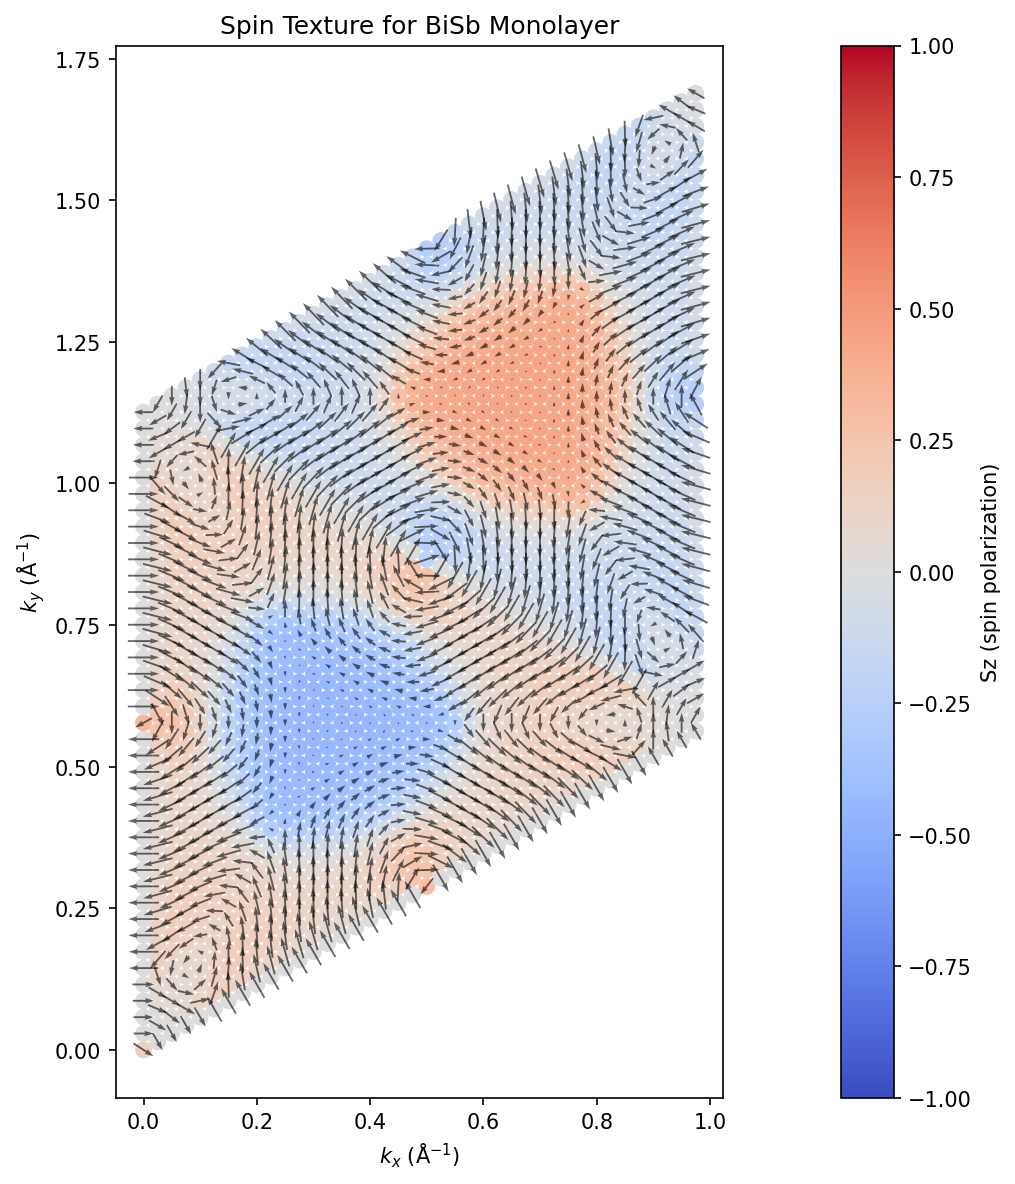

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

kx, ky, Sx,Sy,Sz = bands[21][:].T

fig, ax = plt.subplots(figsize=(16, 8))

    # Background: scatter colored by Sz
norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx, ky, c=Sz, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

    # Foreground: quiver arrows showing in-plane spin (Sx, Sy)
ax.quiver(kx, ky, Sx, Sy,
            pivot="mid",
            scale=8,          # lower = longer arrows; tune to your grid
            scale_units="xy",
            width=0.003,
            color="black",
            alpha=0.6,
            zorder=2)

ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
ax.set_title("Spin Texture for BiSb Monolayer")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

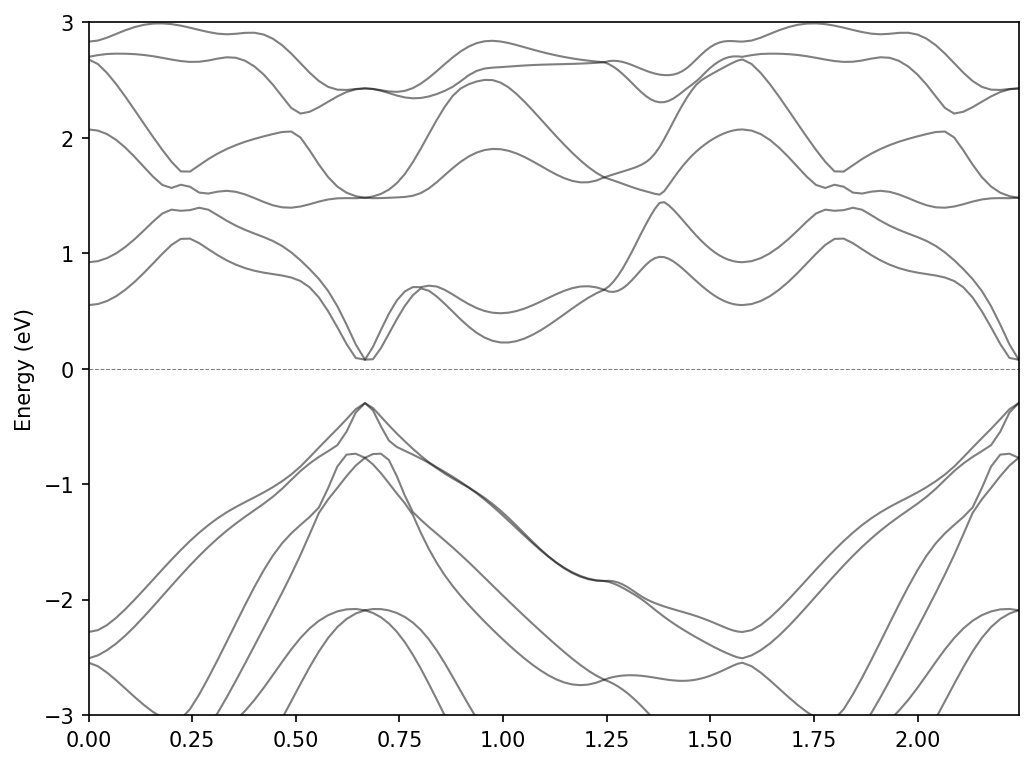

In [35]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np

# load data
data = np.loadtxt('bisb_bands.dat.gnu')

fermi = -0.8111

high_symmetry_points = [0, 0.6667, 1.2440, 1.5774, 2.2440]
labels = ['K', '$\Gamma$', 'M', 'K', '$\Gamma$']

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

for band in range(len(bands)):
    plt.plot(k, bands[band, :]-fermi, linewidth=1, alpha=0.5, color='k')

plt.xlim(min(k),max(k))
plt.ylim(-3,3)
plt.axhline(0,lw=0.5,color="gray",ls="--")
#plt.xticks(high_sym_points,high_sym_labels)
plt.ylabel("Energy (eV)")
plt.show()